In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, cv2, shutil, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, TimeDistributed,
                                     GlobalAveragePooling2D,
                                     LSTM, Dense, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ModelCheckpoint,
                                        ReduceLROnPlateau)

In [3]:
if not os.path.exists("/content/dataset"):
    print("Copying dataset from Drive... (takes 2-5 mins)")
    shutil.copytree(
        "/content/drive/MyDrive/violence detection ai/dataset",
        "/content/dataset"
    )
    print("Done!")
else:
    print("Dataset already exists!")

Copying dataset from Drive... (takes 2-5 mins)
Done!


In [4]:
IMG_SIZE        = 224
SEQUENCE_LENGTH = 16
BATCH_SIZE      = 8
CLASSES         = ["nonviolent", "violent"]
BASE_PATH       = "/content/dataset"

In [5]:
def extract_frames_from_video(video_path):
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []
    if total < SEQUENCE_LENGTH:
        cap.release()
        return []
    step = total // SEQUENCE_LENGTH
    for i in range(SEQUENCE_LENGTH):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = frame / 255.0
        frames.append(frame)
    cap.release()
    return frames

In [6]:
def augment_frame(frame):
    if np.random.rand() < 0.5:
        frame = cv2.flip(frame, 1)
    factor = np.random.uniform(0.7, 1.3)
    frame  = np.clip(frame * factor, 0, 1)
    angle = np.random.uniform(-15, 15)
    h, w  = frame.shape[:2]
    M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    frame = cv2.warpAffine(frame, M, (w, h))
    return frame

In [7]:
def video_generator(split, batch_size=8, augment=False):
    all_samples = []
    for label, cls in enumerate(CLASSES):
        folder = os.path.join(BASE_PATH, split, cls)
        for video_file in os.listdir(folder):
            all_samples.append((os.path.join(folder, video_file), label))

    np.random.shuffle(all_samples)
    print(f"{split}: {len(all_samples)} videos | augment={augment}")

    while True:
        for i in range(0, len(all_samples), batch_size):
            batch = all_samples[i : i + batch_size]
            X, y  = [], []
            for video_path, label in batch:
                frames = extract_frames_from_video(video_path)
                if len(frames) == SEQUENCE_LENGTH:
                    if augment:
                        frames = [augment_frame(f) for f in frames]
                    X.append(frames)
                    y.append(label)
            if X:
                yield np.array(X), np.array(y)

In [8]:
import gc

def preprocess_and_save(split):
    for label, cls in enumerate(CLASSES):
        folder = os.path.join(BASE_PATH, split, cls)
        videos = os.listdir(folder)
        print(f"Processing {split}/{cls} — {len(videos)} videos...")
        X, y = [], []
        for i, video_file in enumerate(videos):
            frames = extract_frames_from_video(os.path.join(folder, video_file))
            if len(frames) == SEQUENCE_LENGTH:
                X.append(frames)
                y.append(label)
            # Save every 200 videos to free RAM
            if (i + 1) % 200 == 0:
                print(f"  Saved checkpoint at {i+1} videos...")
                np.save(f"/content/{split}_{cls}_X_{i}.npy", np.array(X, dtype=np.float32))
                np.save(f"/content/{split}_{cls}_y_{i}.npy", np.array(y, dtype=np.float32))
                X, y = [], []
                gc.collect()
        # Save remaining
        if X:
            np.save(f"/content/{split}_{cls}_X_final.npy", np.array(X, dtype=np.float32))
            np.save(f"/content/{split}_{cls}_y_final.npy", np.array(y, dtype=np.float32))
        print(f"{split}/{cls} done!")

preprocess_and_save("train")
preprocess_and_save("val")
preprocess_and_save("test")
print("All done!")

Processing train/nonviolent — 969 videos...
  Saved checkpoint at 200 videos...
  Saved checkpoint at 400 videos...
  Saved checkpoint at 600 videos...
  Saved checkpoint at 800 videos...
train/nonviolent done!
Processing train/violent — 1090 videos...
  Saved checkpoint at 200 videos...
  Saved checkpoint at 400 videos...
  Saved checkpoint at 600 videos...
  Saved checkpoint at 800 videos...
  Saved checkpoint at 1000 videos...
train/violent done!
Processing val/nonviolent — 385 videos...
  Saved checkpoint at 200 videos...
val/nonviolent done!
Processing val/violent — 436 videos...
  Saved checkpoint at 200 videos...
  Saved checkpoint at 400 videos...
val/violent done!
Processing test/nonviolent — 368 videos...
  Saved checkpoint at 200 videos...
test/nonviolent done!
Processing test/violent — 438 videos...
  Saved checkpoint at 200 videos...
  Saved checkpoint at 400 videos...
test/violent done!
All done!


In [9]:
import glob, gc
import numpy as np

SAVE_PATH = "/content/drive/MyDrive/violence detection ai/numpy_data"

def merge_chunks(split):
    X_all, y_all = [], []
    for cls in CLASSES:
        x_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_X_*.npy"))
        y_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_y_*.npy"))
        print(f"{split}/{cls} — found {len(x_files)} chunks")
        for xf, yf in zip(x_files, y_files):
            X_all.append(np.load(xf))
            y_all.append(np.load(yf))
    X = np.concatenate(X_all, axis=0)
    y = np.concatenate(y_all, axis=0)
    np.save(f"{SAVE_PATH}/{split}_X.npy", X)
    np.save(f"{SAVE_PATH}/{split}_y.npy", y)
    print(f"{split} merged — X:{X.shape} y:{y.shape}")
    gc.collect()

merge_chunks("train")
merge_chunks("val")
merge_chunks("test")
print("Merge done!")

train/nonviolent — found 0 chunks
train/violent — found 0 chunks


ValueError: need at least one array to concatenate

In [10]:
import os
files = os.listdir('/content/drive/MyDrive/violence detection ai/numpy_data')
print(f"Found {len(files)} files:")
for f in sorted(files):
    print(f)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/violence detection ai/numpy_data'

In [11]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Classroom', 'Untitled form (Responses) (4).gsheet', '20240109_164817.jpg', 'Untitled form (Responses) (3).gsheet', 'Untitled form (Responses) (2).gsheet', 'Untitled form (Responses) (1).gsheet', 'Untitled form (1).gform', 'Untitled form.gform', 'Untitled form (Responses).gsheet', 'Introduction from 1st Text Book.pptx', 'mc', '2023 - JULY _AUGUST - SUPPLE PRIOR TO 2021 BATCH', '2023 - DEC & 2024 - MARCH, MAY - SEE, MAKUP - ODD SEM -UG& PG', '2023 - APRIL - MAY- JUNE - QP - SEMESTER END EXMINATIONS_ AND MAKEUP EXAMS', '2022 - SEP -N0V - QP -SUPPLE SEMESTER UG & PG', '339419700060652_signed.pdf', 'Copy of DSA SHEET (1).gsheet', 'Copy of DSA by Shradha Didi & Aman Bhaiya.gsheet', 'Dataset (1)', 'Dataset', '1-99cec0ab-c2f6-4fee-92b3-4a697a8746ef.pdf', 'SE .drawio', 'Document from Lakshmi.pdf', 'ML3.pdf', 'ML2.pdf', 'ML1.pdf', 'research papers', 'ML –Based System Daemon for Log Analysis1 updated.pptx.pdf', 'Tutorial-3-4-5.gdoc', 'Copy of DSA SHEET.gsheet', 'Screenshot_20

In [12]:
import gc, os, glob
import numpy as np

SAVE_PATH = "/content/drive/MyDrive/violence detection ai/numpy_data"
os.makedirs(SAVE_PATH, exist_ok=True)
print("Folder created:", os.path.exists(SAVE_PATH))

def preprocess_and_save(split):
    for label, cls in enumerate(CLASSES):
        folder = os.path.join(BASE_PATH, split, cls)
        videos = os.listdir(folder)
        print(f"Processing {split}/{cls} — {len(videos)} videos...")
        X, y = [], []
        for i, video_file in enumerate(videos):
            frames = extract_frames_from_video(os.path.join(folder, video_file))
            if len(frames) == SEQUENCE_LENGTH:
                X.append(frames)
                y.append(label)
            if (i + 1) % 200 == 0:
                chunk_id = (i + 1) // 200
                np.save(f"{SAVE_PATH}/{split}_{cls}_X_{chunk_id}.npy", np.array(X, dtype=np.float32))
                np.save(f"{SAVE_PATH}/{split}_{cls}_y_{chunk_id}.npy", np.array(y, dtype=np.float32))
                print(f"  Chunk {chunk_id} saved to Drive!")
                X, y = [], []
                gc.collect()
        if X:
            np.save(f"{SAVE_PATH}/{split}_{cls}_X_final.npy", np.array(X, dtype=np.float32))
            np.save(f"{SAVE_PATH}/{split}_{cls}_y_final.npy", np.array(y, dtype=np.float32))
            print(f"  Final chunk saved to Drive!")
        print(f"{split}/{cls} done!")

preprocess_and_save("train")
preprocess_and_save("val")
preprocess_and_save("test")
print("All done!")

Folder created: True
Processing train/nonviolent — 969 videos...
  Chunk 1 saved to Drive!
  Chunk 2 saved to Drive!
  Chunk 3 saved to Drive!
  Chunk 4 saved to Drive!
  Final chunk saved to Drive!
train/nonviolent done!
Processing train/violent — 1090 videos...
  Chunk 1 saved to Drive!
  Chunk 2 saved to Drive!
  Chunk 3 saved to Drive!
  Chunk 4 saved to Drive!
  Chunk 5 saved to Drive!
  Final chunk saved to Drive!
train/violent done!
Processing val/nonviolent — 385 videos...
  Chunk 1 saved to Drive!
  Final chunk saved to Drive!
val/nonviolent done!
Processing val/violent — 436 videos...
  Chunk 1 saved to Drive!
  Chunk 2 saved to Drive!
  Final chunk saved to Drive!
val/violent done!
Processing test/nonviolent — 368 videos...
  Chunk 1 saved to Drive!
  Final chunk saved to Drive!
test/nonviolent done!
Processing test/violent — 438 videos...
  Chunk 1 saved to Drive!
  Chunk 2 saved to Drive!
  Final chunk saved to Drive!
test/violent done!
All done!


In [1]:
import glob, gc
import numpy as np

SAVE_PATH = "/content/drive/MyDrive/violence detection ai/numpy_data"

def merge_chunks(split):
    X_all, y_all = [], []
    for cls in CLASSES:
        x_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_X_*.npy"))
        y_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_y_*.npy"))
        print(f"{split}/{cls} — found {len(x_files)} chunks")
        for xf, yf in zip(x_files, y_files):
            X_all.append(np.load(xf))
            y_all.append(np.load(yf))
    X = np.concatenate(X_all, axis=0)
    y = np.concatenate(y_all, axis=0)
    np.save(f"{SAVE_PATH}/{split}_X.npy", X)
    np.save(f"{SAVE_PATH}/{split}_y.npy", y)
    print(f"{split} merged — X:{X.shape} y:{y.shape}")
    gc.collect()

merge_chunks("train")
merge_chunks("val")
merge_chunks("test")
print("Merge done!")

NameError: name 'CLASSES' is not defined

In [1]:
import os, cv2, shutil, random
import numpy as np
import glob, gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, TimeDistributed,
                                     GlobalAveragePooling2D,
                                     LSTM, Dense, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ModelCheckpoint,
                                        ReduceLROnPlateau)

In [2]:
IMG_SIZE        = 224
SEQUENCE_LENGTH = 16
BATCH_SIZE      = 8
CLASSES         = ["nonviolent", "violent"]
BASE_PATH       = "/content/dataset"
SAVE_PATH       = "/content/drive/MyDrive/violence detection ai/numpy_data"

In [1]:
import glob, gc
import numpy as np

SAVE_PATH = "/content/drive/MyDrive/violence detection ai/numpy_data"

def merge_chunks(split):
    X_all, y_all = [], []
    for cls in CLASSES:
        x_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_X_*.npy"))
        y_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_y_*.npy"))
        print(f"{split}/{cls} — found {len(x_files)} chunks")
        for xf, yf in zip(x_files, y_files):
            X_all.append(np.load(xf))
            y_all.append(np.load(yf))
    X = np.concatenate(X_all, axis=0)
    y = np.concatenate(y_all, axis=0)
    np.save(f"{SAVE_PATH}/{split}_X.npy", X)
    np.save(f"{SAVE_PATH}/{split}_y.npy", y)
    print(f"{split} merged — X:{X.shape} y:{y.shape}")
    gc.collect()

merge_chunks("train")
merge_chunks("val")
merge_chunks("test")
print("Merge done!")

NameError: name 'CLASSES' is not defined

In [2]:
import os, numpy as np, glob, gc
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, TimeDistributed,
                                     GlobalAveragePooling2D,
                                     LSTM, Dense, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ModelCheckpoint,
                                        ReduceLROnPlateau)

CLASSES   = ["nonviolent", "violent"]
SAVE_PATH = "/content/drive/MyDrive/violence detection ai/numpy_data"
print("Ready!")

Ready!


In [3]:
base_model = MobileNetV3Large(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
for layer in base_model.layers[:100]:
    layer.trainable = False

model = Sequential([
    Input(shape=(16, 224, 224, 3)),
    TimeDistributed(base_model),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(128),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("Model ready!")

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model ready!


In [1]:
def load_split(split):
    X_all, y_all = [], []
    for cls in CLASSES:
        x_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_X_*.npy"))
        y_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_y_*.npy"))
        for xf, yf in zip(x_files, y_files):
            X_all.append(np.load(xf))
            y_all.append(np.load(yf))
    return np.concatenate(X_all), np.concatenate(y_all)

print("Loading val data...")
X_val, y_val = load_split("val")
print(f"Val: {X_val.shape}")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(f"{SAVE_PATH}/best_model.h5",
                    monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, verbose=1)
]

# Train chunk by chunk
EPOCHS = 20
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    x_files = sorted(glob.glob(f"{SAVE_PATH}/train_*_X_*.npy"))
    y_files = sorted(glob.glob(f"{SAVE_PATH}/train_*_y_*.npy"))
    for xf, yf in zip(x_files, y_files):
        X_chunk = np.load(xf)
        y_chunk = np.load(yf)
        sw = np.where(y_chunk == 1, 1.12, 1.0)
        model.train_on_batch(X_chunk, y_chunk, sample_weight=sw)
        del X_chunk, y_chunk
        gc.collect()
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"val_loss: {val_loss:.4f} — val_accuracy: {val_acc:.4f}")

model.save(f"{SAVE_PATH}/best_model.h5")
print("Training complete!")

Loading val data...


NameError: name 'CLASSES' is not defined

In [1]:
import os, numpy as np, glob, gc
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, TimeDistributed,
                                     GlobalAveragePooling2D,
                                     LSTM, Dense, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

CLASSES   = ["nonviolent", "violent"]
SAVE_PATH = "/content/drive/MyDrive/violence detection ai/numpy_data"

# Build model
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers[:100]:
    layer.trainable = False

model = Sequential([
    Input(shape=(16, 224, 224, 3)),
    TimeDistributed(base_model),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(128),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])
print("Model ready!")

# Load data chunk by chunk using tf.data
def numpy_chunk_generator(split):
    for cls in CLASSES:
        x_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_X_*.npy"))
        y_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_y_*.npy"))
        for xf, yf in zip(x_files, y_files):
            X = np.load(xf)
            y = np.load(yf)
            for i in range(len(X)):
                yield X[i], y[i]
            del X, y
            gc.collect()

def make_dataset(split, batch_size=8, shuffle=False):
    ds = tf.data.Dataset.from_generator(
        lambda: numpy_chunk_generator(split),
        output_signature=(
            tf.TensorSpec(shape=(16, 224, 224, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.float32)
        )
    )
    if shuffle:
        ds = ds.shuffle(200)
    ds = ds.batch(batch_size).prefetch(2)
    return ds

print("Creating datasets...")
train_ds = make_dataset("train", batch_size=8, shuffle=True)
val_ds   = make_dataset("val",   batch_size=8, shuffle=False)
print("Datasets ready!")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(f"{SAVE_PATH}/best_model.h5", monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

# Train
train_steps = 2059 // 8
val_steps   = 821  // 8

history = model.fit(
    train_ds,
    steps_per_epoch=train_steps,
    validation_data=val_ds,
    validation_steps=val_steps,
    epochs=20,
    callbacks=callbacks
)
print("Training complete!")

Model ready!
Creating datasets...
Datasets ready!
Epoch 1/20


KeyboardInterrupt: 

In [ ]:
import os, numpy as np, glob, gc
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, TimeDistributed,
                                     GlobalAveragePooling2D,
                                     LSTM, Dense, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

CLASSES   = ["nonviolent", "violent"]
SAVE_PATH = "/content/drive/MyDrive/violence detection ai/numpy_data"

# Mount drive
from google.colab import drive
drive.mount('/content/drive')

# Build model
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers[:100]:
    layer.trainable = False

model = Sequential([
    Input(shape=(16, 224, 224, 3)),
    TimeDistributed(base_model),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(128),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])
print("Model ready!")

# tf.data pipeline
def numpy_chunk_generator(split):
    for cls in CLASSES:
        x_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_X_*.npy"))
        y_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_y_*.npy"))
        for xf, yf in zip(x_files, y_files):
            X = np.load(xf)
            y = np.load(yf)
            for i in range(len(X)):
                yield X[i], y[i]
            del X, y
            gc.collect()

def make_dataset(split, batch_size=8, shuffle=False):
    ds = tf.data.Dataset.from_generator(
        lambda: numpy_chunk_generator(split),
        output_signature=(
            tf.TensorSpec(shape=(16, 224, 224, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.float32)
        )
    )
    if shuffle:
        ds = ds.shuffle(200)
    ds = ds.batch(batch_size).prefetch(2)
    return ds

print("Creating datasets...")
train_ds = make_dataset("train", batch_size=8, shuffle=True)
val_ds   = make_dataset("val",   batch_size=8, shuffle=False)
print("Datasets ready!")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(f"{SAVE_PATH}/best_model.h5", monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

# Train
history = model.fit(
    train_ds,
    steps_per_epoch=2059//8,
    validation_data=val_ds,
    validation_steps=821//8,
    epochs=20,
    callbacks=callbacks
)
print("Training complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model ready!
Creating datasets...
Datasets ready!
Epoch 1/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9298 - loss: 0.2486
Epoch 1: val_loss improved from None to 2.28654, saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.h5
257/257 ━━━━━━━━━━━━━━━━━━━━ 3107s 11s/step - accuracy: 0.9193 - loss: 0.2656 - val_accuracy: 0.5282 - val_loss: 2.2865 - learning_rate: 1.0000e-04
Epoch 2/20
  1/257 ━━━━━━━━━━━━━━━━━━━━ 12:05 3s/step - accuracy: 1.0000 - loss: 0.0067

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 2.28654
257/257 ━━━━━━━━━━━━━━━━━━━━ 378s 1s/step - accuracy: 1.0000 - loss: 0.0067 - val_accuracy: 0.5282 - val_loss: 2.2978 - learning_rate: 1.0000e-04
Epoch 3/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6844 - loss: 1.1172
Epoch 3: val_loss improved from 2.28654 to 2.09613, saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.h5
257/257 ━━━━━━━━━━━━━━━━━━━━ 3327s 13s/step - accuracy: 0.8356 - loss: 0.5092 - val_accuracy: 0.5282 - val_loss: 2.0961 - learning_rate: 1.0000e-04
Epoch 4/20
  1/257 ━━━━━━━━━━━━━━━━━━━━ 11:50 3s/step - accuracy: 1.0000 - loss: 0.0236
Epoch 4: val_loss did not improve from 2.09613
257/257 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 1.0000 - loss: 0.0236 - val_accuracy: 0.5282 - val_loss: 2.1046 - learning_rate: 1.0000e-04
Epoch 5/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.6144 - loss: 1.1315 
Epoch 5: val_loss improved from 2.09613 to 1.66918, saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.h5
257/257 ━━━━━━━━━━━━━━━━━━━━ 4019s 15s/step - accuracy: 0.8001 - loss: 0.5572 - val_accuracy: 0.5282 - val_loss: 1.6692 - learning_rate: 1.0000e-04
Epoch 6/20
  1/257 ━━━━━━━━━━━━━━━━━━━━ 17:27 4s/step - accuracy: 1.0000 - loss: 0.0348
Epoch 6: val_loss did not improve from 1.66918
257/257 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - accuracy: 1.0000 - loss: 0.0348 - val_accuracy: 0.5282 - val_loss: 1.6749 - learning_rate: 1.0000e-04
Epoch 7/20


In [1]:
import os, numpy as np, glob, gc
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, TimeDistributed,
                                     GlobalAveragePooling2D,
                                     LSTM, Dense, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from google.colab import drive

drive.mount('/content/drive')

CLASSES   = ["nonviolent", "violent"]
SAVE_PATH = "/content/drive/MyDrive/violence detection ai/numpy_data"

# Lighter model - MobileNetV2 instead of V3, smaller LSTM
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(112,112,3))
base_model.trainable = False  # freeze ALL layers to save RAM

model = Sequential([
    Input(shape=(16, 112, 112, 3)),  # smaller frames
    TimeDistributed(base_model),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(64),                         # smaller LSTM
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])
print("Model ready!")

# Generator - resize frames to 112x112 on the fly
def numpy_chunk_generator(split):
    for cls in CLASSES:
        x_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_X_*.npy"))
        y_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_y_*.npy"))
        for xf, yf in zip(x_files, y_files):
            X = np.load(xf)
            # resize from 224 to 112
            X = X[:, :, ::2, ::2, :]  # fast downscale by factor 2
            y = np.load(yf)
            for i in range(len(X)):
                yield X[i], y[i]
            del X, y
            gc.collect()

def make_dataset(split, batch_size=4, shuffle=False):
    ds = tf.data.Dataset.from_generator(
        lambda: numpy_chunk_generator(split),
        output_signature=(
            tf.TensorSpec(shape=(16, 112, 112, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.float32)
        )
    )
    if shuffle:
        ds = ds.shuffle(100)
    ds = ds.batch(batch_size).prefetch(1)
    return ds

print("Creating datasets...")
train_ds = make_dataset("train", batch_size=4, shuffle=True)
val_ds   = make_dataset("val",   batch_size=4, shuffle=False)
print("Datasets ready!")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(f"{SAVE_PATH}/best_model.h5", monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    train_ds,
    steps_per_epoch=2059//4,
    validation_data=val_ds,
    validation_steps=821//4,
    epochs=20,
    callbacks=callbacks
)
print("Training complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_172929/4242208455.py:18: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(112,112,3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model ready!
Creating datasets...
Datasets ready!
Epoch 1/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9389 - loss: 0.2332
Epoch 1: val_loss improved from None to 1.78660, saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.h5
514/514 ━━━━━━━━━━━━━━━━━━━━ 900s 2s/step - accuracy: 0.9266 - loss: 0.2620 - val_accuracy: 0.5305 - val_loss: 1.7866 - learning_rate: 1.0000e-04
Epoch 2/20
  1/514 ━━━━━━━━━━━━━━━━━━━━ 5:42 668ms/step - accuracy: 1.0000 - loss: 0.1768

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 1.78660
514/514 ━━━━━━━━━━━━━━━━━━━━ 196s 381ms/step - accuracy: 1.0000 - loss: 0.1768 - val_accuracy: 0.5305 - val_loss: 1.7896 - learning_rate: 1.0000e-04
Epoch 3/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6741 - loss: 0.9328
Epoch 3: val_loss improved from 1.78660 to 1.42102, saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.h5
514/514 ━━━━━━━━━━━━━━━━━━━━ 1031s 2s/step - accuracy: 0.8375 - loss: 0.4725 - val_accuracy: 0.5305 - val_loss: 1.4210 - learning_rate: 1.0000e-04
Epoch 4/20
  1/514 ━━━━━━━━━━━━━━━━━━━━ 5:32 649ms/step - accuracy: 1.0000 - loss: 0.0870
Epoch 4: val_loss did not improve from 1.42102
514/514 ━━━━━━━━━━━━━━━━━━━━ 203s 395ms/step - accuracy: 1.0000 - loss: 0.0870 - val_accuracy: 0.5305 - val_loss: 1.4237 - learning_rate: 1.0000e-04
Epoch 5/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6319 - loss: 0.8675
Epoch 5: val_loss improved from 1.42102 to 1.28665, saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.h5
514/514 ━━━━━━━━━━━━━━━━━━━━ 961s 2s/step - accuracy: 0.8200 - loss: 0.4755 - val_accuracy: 0.5305 - val_loss: 1.2866 - learning_rate: 1.0000e-04
Epoch 6/20
  1/514 ━━━━━━━━━━━━━━━━━━━━ 3:22 395ms/step - accuracy: 1.0000 - loss: 0.0278
Epoch 6: val_loss did not improve from 1.28665
514/514 ━━━━━━━━━━━━━━━━━━━━ 163s 316ms/step - accuracy: 1.0000 - loss: 0.0278 - val_accuracy: 0.5305 - val_loss: 1.2887 - learning_rate: 1.0000e-04
Epoch 7/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6903 - loss: 0.7538
Epoch 7: val_loss did not improve from 1.28665

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
514/514 ━━━━━━━━━━━━━━━━━━━━ 913s 2s/step - accuracy: 0.8546 - loss: 0.4096 - val_accuracy: 0.5305 - val_loss: 1.3725 - learning_rate: 1.0000e-04
Epoch 8/20
  1/514 ━━━━━━━━━━━━━━━━━━━━ 3:13 378ms/step - accuracy: 1.0000 - loss: 0.0720
Epoch 8: val_loss 

In [2]:
import os, numpy as np, glob, gc
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, TimeDistributed,
                                     GlobalAveragePooling2D,
                                     LSTM, Dense, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

CLASSES   = ["nonviolent", "violent"]
SAVE_PATH = "/content/drive/MyDrive/violence detection ai/numpy_data"

# Build model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = Sequential([
    Input(shape=(16, 112, 112, 3)),
    TimeDistributed(base_model),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(64),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])
print("Model ready!")

# Generator
def numpy_chunk_generator(split):
    while True:  # loop forever so .repeat() works properly
        for cls in CLASSES:
            x_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_X_*.npy"))
            y_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_y_*.npy"))
            for xf, yf in zip(x_files, y_files):
                X = np.load(xf)
                X = X[:, :, ::2, ::2, :]  # resize 224→112
                y = np.load(yf)
                for i in range(len(X)):
                    yield X[i], y[i]
                del X, y
                gc.collect()

def make_dataset(split, batch_size=4, shuffle=False):
    ds = tf.data.Dataset.from_generator(
        lambda: numpy_chunk_generator(split),
        output_signature=(
            tf.TensorSpec(shape=(16, 112, 112, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.float32)
        )
    )
    if shuffle:
        ds = ds.shuffle(100)
    ds = ds.batch(batch_size).prefetch(1)
    return ds

print("Creating datasets...")
train_ds = make_dataset("train", batch_size=4, shuffle=True)
val_ds   = make_dataset("val",   batch_size=4, shuffle=False)
print("Datasets ready!")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(f"{SAVE_PATH}/best_model.keras",
                    monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, verbose=1)
]

# Train
history = model.fit(
    train_ds,
    steps_per_epoch=2059//4,
    validation_data=val_ds,
    validation_steps=821//4,
    epochs=20,
    callbacks=callbacks
)
print("Training complete!")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],     label='Train')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train')
ax2.plot(history.history['val_accuracy'], label='Validation')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/training_curves.png")
plt.show()
print("Plots saved!")

Mounted at /content/drive


ValueError: Exception encountered when calling TimeDistributed.call().

[1mInput 0 with name 'input_layer_2' of layer 'mobilenetv2_1.00_224' is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(None, 112, 112, 3)[0m

Arguments received by TimeDistributed.call():
  • args=('<KerasTensor shape=(None, 16, 112, 112, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_317>',)
  • kwargs={'mask': 'None'}

Mounted at /content/drive


/tmp/ipykernel_2770/1788067929.py:19: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model ready!
Creating datasets...
Datasets ready!
Epoch 1/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9581 - loss: 0.2159
Epoch 1: val_loss improved from None to 1.32092, saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.keras
514/514 ━━━━━━━━━━━━━━━━━━━━ 959s 2s/step - accuracy: 0.9266 - loss: 0.3055 - val_accuracy: 0.5305 - val_loss: 1.3209 - learning_rate: 1.0000e-04
Epoch 2/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7737 - loss: 0.5356
Epoch 2: val_loss improved from 1.32092 to 1.21546, saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/violence detection ai/numpy_data/best_model.keras
514/514 ━━━━━━━━━━━━━━━━━━━━ 1093s 2s/step - accuracy: 0.8521 - loss: 0.3981 - val_accurac

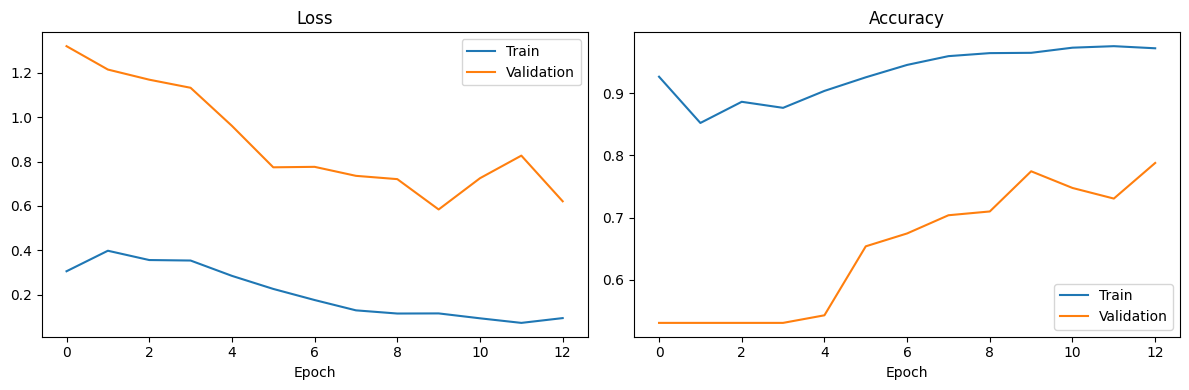

Plots saved!


In [1]:
import os, numpy as np, glob, gc
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, TimeDistributed,
                                     GlobalAveragePooling2D,
                                     LSTM, Dense, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

CLASSES   = ["nonviolent", "violent"]
SAVE_PATH = "/content/drive/MyDrive/violence detection ai/numpy_data"

# Build model with 112x112
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(112, 112, 3)  # match 112x112
)
base_model.trainable = False

model = Sequential([
    Input(shape=(16, 112, 112, 3)),  # match 112x112
    TimeDistributed(base_model),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(64),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])
print("Model ready!")

# Generator
def numpy_chunk_generator(split):
    while True:
        for cls in CLASSES:
            x_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_X_*.npy"))
            y_files = sorted(glob.glob(f"{SAVE_PATH}/{split}_{cls}_y_*.npy"))
            for xf, yf in zip(x_files, y_files):
                X = np.load(xf)
                X = X[:, :, ::2, ::2, :]  # 224→112
                y = np.load(yf)
                for i in range(len(X)):
                    yield X[i], y[i]
                del X, y
                gc.collect()

def make_dataset(split, batch_size=4, shuffle=False):
    ds = tf.data.Dataset.from_generator(
        lambda: numpy_chunk_generator(split),
        output_signature=(
            tf.TensorSpec(shape=(16, 112, 112, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.float32)
        )
    )
    if shuffle:
        ds = ds.shuffle(100)
    ds = ds.batch(batch_size).prefetch(1)
    return ds

print("Creating datasets...")
train_ds = make_dataset("train", batch_size=4, shuffle=True)
val_ds   = make_dataset("val",   batch_size=4, shuffle=False)
print("Datasets ready!")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(f"{SAVE_PATH}/best_model.keras",
                    monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, verbose=1)
]

# Train
history = model.fit(
    train_ds,
    steps_per_epoch=2059//4,
    validation_data=val_ds,
    validation_steps=821//4,
    epochs=20,
    callbacks=callbacks
)
print("Training complete!")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],     label='Train')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train')
ax2.plot(history.history['val_accuracy'], label='Validation')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/training_curves.png")
plt.show()
print("Plots saved!")